---
**ISBM COLLEGE OF ENGINEERING**  
**SUBJECT**: BDA LAB  
**STUDENT NAME**: RUSHIL CHAITANYA DHUBE  
**ROLL NUMBER**: 12  
**YEAR**: BE (2025-2026)  
**PRACTICAL**: 5

---

# MapReduce Implementation for Movie Rating Analysis

## Lab Objectives:
1. Understand the MapReduce workflow
2. Implement map and reduce functions
3. Process the movie ratings dataset
4. Compute average ratings per movie
5. Compare MapReduce with Pandas
6. Visualize the key results

In [25]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
import os
import warnings

# Suppress warnings in notebook output
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

## Step 1: Load and Explore Movies Dataset

In [26]:
print("=" * 70)
print("STEP 1: LOAD AND PREPARE MOVIES DATASET")
print("=" * 70)

dataset_file = 'movies.csv'

if os.path.exists(dataset_file):
    raw_df = pd.read_csv(dataset_file)
    print("Dataset loaded successfully")
else:
    raise FileNotFoundError("movies.csv not found in the current folder")

required_cols = ['id', 'title', 'director', 'genres', 'release_date', 'vote_average', 'vote_count']
missing_cols = [c for c in required_cols if c not in raw_df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

prep_df = raw_df[required_cols].copy()
prep_df = prep_df.dropna(subset=['id', 'vote_average'])
prep_df['id'] = pd.to_numeric(prep_df['id'], errors='coerce')
prep_df['vote_average'] = pd.to_numeric(prep_df['vote_average'], errors='coerce')
prep_df['vote_count'] = pd.to_numeric(prep_df['vote_count'], errors='coerce').fillna(0)
prep_df = prep_df.dropna(subset=['id', 'vote_average'])
prep_df['rating'] = (prep_df['vote_average'] / 2.0).clip(lower=0, upper=5)

movie_meta = prep_df.set_index('id')[['title', 'director', 'genres', 'release_date', 'vote_count']].to_dict('index')

df = prep_df.rename(columns={'id': 'movie_id'})[['movie_id', 'vote_count', 'rating']]
df['user_id'] = df['vote_count'].round().astype(int)
df['timestamp'] = pd.Timestamp('2023-01-01').timestamp()
df = df[['movie_id', 'user_id', 'rating', 'timestamp']]

print(f"Prepared data: {df.shape[0]} records, {df.shape[1]} columns")
print(f"Columns: {df.columns.tolist()}")
print(f"Missing values: {df.isnull().sum().sum()}")

STEP 1: LOAD AND PREPARE MOVIES DATASET
Dataset loaded successfully
Prepared data: 4803 records, 4 columns
Columns: ['movie_id', 'user_id', 'rating', 'timestamp']
Missing values: 0


## Step 2: MapReduce Implementation

In [27]:
print("=" * 70)
print("STEP 2: MAPREDUCE IMPLEMENTATION")
print("=" * 70)

def map_function(record):
    """Extract movie_id and rating from each record."""
    try:
        if isinstance(record, (list, tuple, np.ndarray)):
            movie_id = int(float(record[0]))
            rating = float(record[2])
            return (movie_id, rating)

        parts = str(record).replace(',', ' ').split()
        movie_id = int(float(parts[0]))
        rating = float(parts[2])
        return (movie_id, rating)
    except Exception as e:
        print(f"Error processing record: {e}")
        return None

def reduce_function(movie_ratings):
    """Calculate average rating for each movie."""
    result = {}
    for movie_id, ratings in movie_ratings.items():
        if ratings:
            total_rating = sum(ratings)
            count = len(ratings)
            result[movie_id] = {
                'average_rating': total_rating / count,
                'total_ratings': count,
                'sum_ratings': total_rating
            }
    return result

print("Map and reduce functions defined")

STEP 2: MAPREDUCE IMPLEMENTATION
Map and reduce functions defined


## Step 3: Execute MapReduce Pipeline

In [28]:
print("=" * 70)
print("STEP 3: EXECUTE MAPREDUCE PIPELINE")
print("=" * 70)

data_lines = df.values.tolist()
mapped_pairs = []
for line in data_lines:
    result = map_function(line)
    if result:
        mapped_pairs.append(result)

movie_ratings = defaultdict(list)
for movie_id, rating in mapped_pairs:
    movie_ratings[movie_id].append(rating)

movie_averages = reduce_function(movie_ratings)

print(f"Records processed: {len(data_lines)}")
print(f"Mapped pairs: {len(mapped_pairs)}")
print(f"Unique movies: {len(movie_ratings)}")
print(f"Reduced movie averages: {len(movie_averages)}")
print("Top 5 movie averages:")

sorted_movies = sorted(movie_averages.items(), key=lambda x: x[1]['average_rating'], reverse=True)
for movie_id, stats in sorted_movies[:5]:
    print(f"  Movie {movie_id}: {stats['average_rating']:.4f} from {stats['total_ratings']} ratings")

STEP 3: EXECUTE MAPREDUCE PIPELINE
Records processed: 4803
Mapped pairs: 4803
Unique movies: 4803
Reduced movie averages: 4803
Top 5 movie averages:
  Movie 89861: 5.0000 from 1 ratings
  Movie 78373: 5.0000 from 1 ratings
  Movie 361505: 5.0000 from 1 ratings
  Movie 40963: 5.0000 from 1 ratings
  Movie 346081: 4.7500 from 1 ratings


## Step 4: Results and Analysis

In [29]:
print("=" * 70)
print("STEP 4: RESULTS AND ANALYSIS")
print("=" * 70)

results_list = []
for movie_id, stats in movie_averages.items():
    meta = movie_meta.get(movie_id, {})
    results_list.append({
        'movie_id': movie_id,
        'title': meta.get('title', 'Unknown'),
        'director': meta.get('director', 'Unknown'),
        'genres': meta.get('genres', 'Unknown'),
        'release_date': meta.get('release_date', 'Unknown'),
        'vote_count': int(meta.get('vote_count', 0)) if pd.notna(meta.get('vote_count', 0)) else 0,
        'average_rating': stats['average_rating'],
        'total_ratings': stats['total_ratings'],
        'sum_ratings': stats['sum_ratings']
    })

results_df = pd.DataFrame(results_list).sort_values('average_rating', ascending=False)

print(f"Total movies: {len(results_df)}")
print(f"Total ratings: {results_df['total_ratings'].sum()}")
print(f"Average rating: {results_df['average_rating'].mean():.4f}")
print(f"Highest rating: {results_df['average_rating'].max():.4f}")
print(f"Lowest rating: {results_df['average_rating'].min():.4f}")
print(f"Median rating: {results_df['average_rating'].median():.4f}")

print("Top 5 highest rated movies:")
print(results_df[['movie_id', 'title', 'average_rating', 'vote_count']].head(5).to_string(index=False))

print("Rating distribution by whole-number bucket:")
for rating_range in [0, 1, 2, 3, 4, 5]:
    if rating_range < 5:
        count = len(results_df[(results_df['average_rating'] >= rating_range) & (results_df['average_rating'] < rating_range + 1)])
    else:
        count = len(results_df[results_df['average_rating'] >= rating_range])
    print(f"  {rating_range}-{rating_range + 1}: {count}")

STEP 4: RESULTS AND ANALYSIS
Total movies: 4803
Total ratings: 4803
Average rating: 3.0461
Highest rating: 5.0000
Lowest rating: 0.0000
Median rating: 3.1000
Top 5 highest rated movies:
 movie_id                 title  average_rating  vote_count
    40963        Little Big Top            5.00           1
    89861      Stiff Upper Lips            5.00           1
    78373 Dancer, Texas Pop. 81            5.00           1
   361505 Me You and Five Bucks            5.00           2
   346081             Sardaarji            4.75           2
Rating distribution by whole-number bucket:
  0-1: 67
  1-2: 105
  2-3: 1659
  3-4: 2887
  4-5: 81
  5-6: 4


## Step 5: Visualization

STEP 5: VISUALIZATION


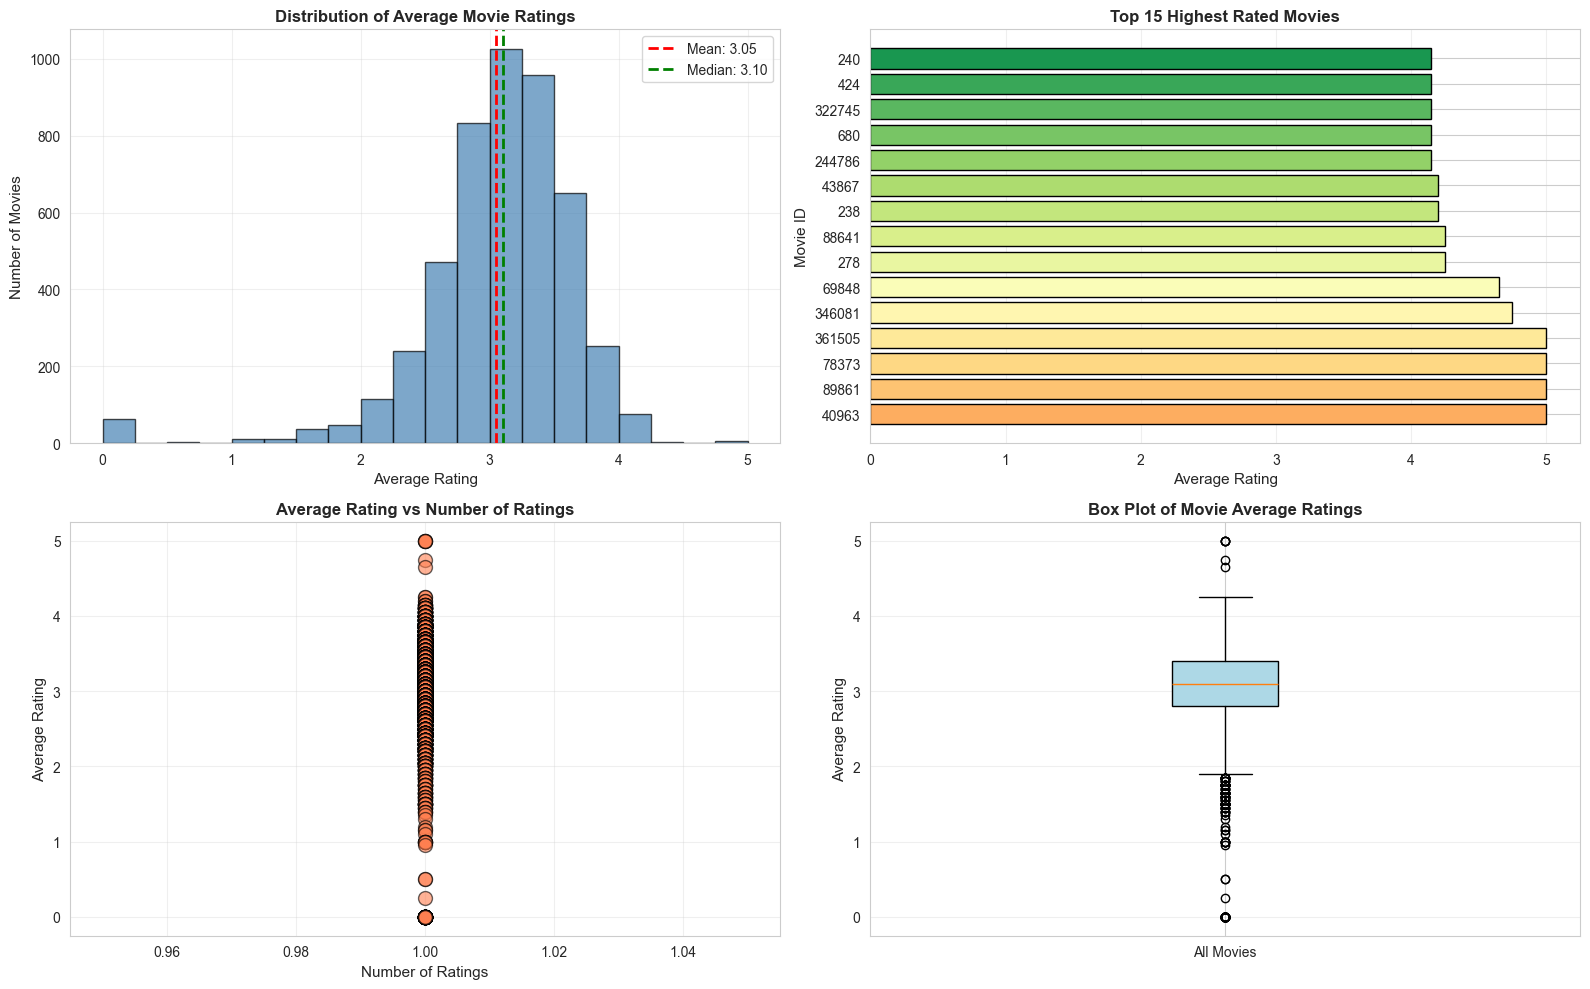

Visualization saved as 'mapreduce_analysis.png'


In [30]:
print("=" * 70)
print("STEP 5: VISUALIZATION")
print("=" * 70)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

ax = axes[0, 0]
ax.hist(results_df['average_rating'], bins=20, color='steelblue', edgecolor='black', alpha=0.7)
ax.axvline(results_df['average_rating'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {results_df['average_rating'].mean():.2f}")
ax.axvline(results_df['average_rating'].median(), color='green', linestyle='--', linewidth=2, label=f"Median: {results_df['average_rating'].median():.2f}")
ax.set_title('Distribution of Average Movie Ratings', fontsize=12, fontweight='bold')
ax.set_xlabel('Average Rating', fontsize=11)
ax.set_ylabel('Number of Movies', fontsize=11)
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[0, 1]
top_15 = results_df.head(15)
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(top_15)))
ax.barh(top_15['movie_id'].astype(str), top_15['average_rating'], color=colors, edgecolor='black')
ax.set_xlabel('Average Rating', fontsize=11)
ax.set_ylabel('Movie ID', fontsize=11)
ax.set_title('Top 15 Highest Rated Movies', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

ax = axes[1, 0]
ax.scatter(results_df['total_ratings'], results_df['average_rating'], alpha=0.6, s=100, color='coral', edgecolor='black')
ax.set_xlabel('Number of Ratings', fontsize=11)
ax.set_ylabel('Average Rating', fontsize=11)
ax.set_title('Average Rating vs Number of Ratings', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

ax = axes[1, 1]
box_plot = ax.boxplot([results_df['average_rating']], labels=['All Movies'], patch_artist=True)
box_plot['boxes'][0].set_facecolor('lightblue')
ax.set_ylabel('Average Rating', fontsize=11)
ax.set_title('Box Plot of Movie Average Ratings', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('mapreduce_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("Visualization saved as 'mapreduce_analysis.png'")

## Step 6: Comparison with Pandas Implementation

In [31]:
print("\n" + "=" * 70)
print("STEP 6: COMPARISON WITH PANDAS IMPLEMENTATION")
print("=" * 70)

# Using Pandas groupby (equivalent to MapReduce)
pandas_results = df.groupby('movie_id')['rating'].agg(['mean', 'count', 'sum']).reset_index()
pandas_results.columns = ['movie_id', 'average_rating', 'total_ratings', 'sum_ratings']
pandas_results = pandas_results.sort_values('average_rating', ascending=False)

print("\nPandas GroupBy Results (Top 10):")
print("-" * 70)
print(pandas_results.head(10).to_string(index=False))

# Verify MapReduce results match Pandas results
print("\n" + "-" * 70)
print("VERIFICATION: MapReduce vs Pandas")
print("-" * 70)

matches = 0
for _, row in pandas_results.iterrows():
    movie_id = int(row['movie_id'])
    pandas_avg = row['average_rating']
    
    if movie_id in movie_averages:
        mapreduce_avg = movie_averages[movie_id]['average_rating']
        if abs(pandas_avg - mapreduce_avg) < 0.0001:
            matches += 1

print(f"Matching Results: {matches} / {len(pandas_results)}")
if matches == len(pandas_results):
    print("\nMapReduce results match Pandas results perfectly!")
else:
    print(f"\nWarning: {len(pandas_results) - matches} discrepancies found")


STEP 6: COMPARISON WITH PANDAS IMPLEMENTATION

Pandas GroupBy Results (Top 10):
----------------------------------------------------------------------
 movie_id  average_rating  total_ratings  sum_ratings
   361505            5.00              1         5.00
    78373            5.00              1         5.00
    40963            5.00              1         5.00
    89861            5.00              1         5.00
   346081            4.75              1         4.75
    69848            4.65              1         4.65
      278            4.25              1         4.25
    88641            4.25              1         4.25
    43867            4.20              1         4.20
      238            4.20              1         4.20

----------------------------------------------------------------------
VERIFICATION: MapReduce vs Pandas
----------------------------------------------------------------------
Matching Results: 4803 / 4803

MapReduce results match Pandas results perfect

## Step 7: Export Results

In [32]:
print("\n" + "=" * 70)
print("STEP 7: EXPORT RESULTS")
print("=" * 70)

# Export MapReduce results to CSV
results_df.to_csv('mapreduce_movie_ratings.csv', index=False)
print("\nExported to 'mapreduce_movie_ratings.csv'")

# Export statistics summary
summary_stats = {
    'Metric': [
        'Total Movies',
        'Total Ratings',
        'Average Rating (All)',
        'Highest Average Rating',
        'Lowest Average Rating',
        'Standard Deviation',
        'Median Rating',
        'Mode Movie ID (Highest Rated)'
    ],
    'Value': [
        len(results_df),
        int(results_df['total_ratings'].sum()),
        f"{results_df['average_rating'].mean():.4f}",
        f"{results_df['average_rating'].max():.4f}",
        f"{results_df['average_rating'].min():.4f}",
        f"{results_df['average_rating'].std():.4f}",
        f"{results_df['average_rating'].median():.4f}",
        int(results_df.loc[results_df['average_rating'].idxmax(), 'movie_id'])
    ]
}
summary_df = pd.DataFrame(summary_stats)
summary_df.to_csv('mapreduce_summary_statistics.csv', index=False)
print("Exported to 'mapreduce_summary_statistics.csv'")

print("\n" + "=" * 70)
print("PRACTICAL EXERCISE COMPLETED SUCCESSFULLY")
print("=" * 70)
print("\nGenerated Files:")
for f in ['mapreduce_movie_ratings.csv', 'mapreduce_summary_statistics.csv', 'mapreduce_analysis.png']:
    if os.path.exists(f):
        size = os.path.getsize(f)
        print(f"  - {f:<40} ({size:,} bytes)")

print("\nAll tasks completed successfully!")


STEP 7: EXPORT RESULTS

Exported to 'mapreduce_movie_ratings.csv'
Exported to 'mapreduce_summary_statistics.csv'

PRACTICAL EXERCISE COMPLETED SUCCESSFULLY

Generated Files:
  - mapreduce_movie_ratings.csv              (397,197 bytes)
  - mapreduce_summary_statistics.csv         (229 bytes)
  - mapreduce_analysis.png                   (384,702 bytes)

All tasks completed successfully!
